In [10]:
import sys
sys.path.append('../data')
import numpy as np
import copy , math
import matplotlib.pyplot as plt
%matplotlib widget
from lab_utils_common import  dlc, plot_data, plt_tumor_data, sigmoid, compute_cost_logistic
from plt_quad_logistic import plt_quad_logistic, plt_prob
plt.style.use('../data/deeplearning.mplstyle')

In [11]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

(np.float64(0.0), np.float64(4.0), np.float64(0.0), np.float64(3.5))

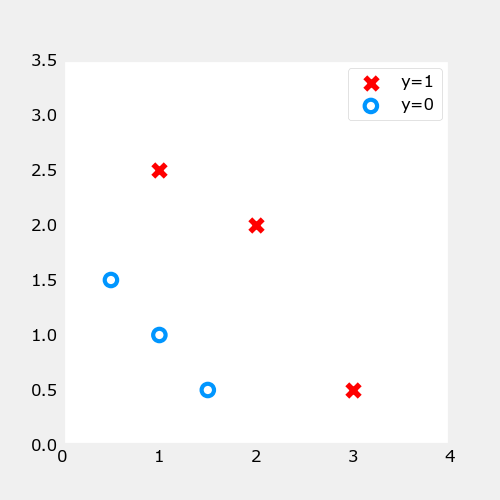

In [12]:
fig,ax = plt.subplots(1,1,figsize = (5,5))

plot_data(X_train,y_train,ax)
ax.axis([0,4,0,3.5])


In [13]:
def compute_gradientdescent(X,y,w,b):
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    for i in range(m):
        z = np.dot(X[i],w) + b
        f_wb_i = sigmoid(z)
        err = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i,j]
        dj_db = dj_db + err

    dj_dw = dj_dw /  m
    dj_db = dj_db /  m

    return dj_dw,dj_db


In [14]:
X_tmp = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2.,3.])
b_tmp = 1.

djdw_tmp, djdb_tmp = compute_gradientdescent(X_tmp,y_tmp,w_tmp,b_tmp)
print(f"djdb : {djdb_tmp}")
print(f"djdw : {djdw_tmp.tolist()}")

djdb : 0.49861806546328574
djdw : [0.498333393278696, 0.49883942983996693]


In [15]:
def gradient_descent(X,y,w_in,b_in,alpha,num_iters):
    J_hist = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        djdw,djdb = compute_gradientdescent(X,y,w,b)

        w = w - alpha * djdw
        b = b - alpha * djdb

        if i < 100000:
            J_hist.append(compute_cost_logistic(X,y,w,b))
        if i%math.ceil(num_iters/10) == 0:
            print(f"Iteration { i:4d} : Cost {J_hist[-1]}   ")
    return w , b , J_hist

In [16]:
w_tmp = np.zeros_like(X_train[0])
b_tmp = 0.
alph = 0.1
iterations = 10000


w_out, b_out, _ = gradient_descent(X_train,y_train,w_tmp,b_tmp,alph,iterations)

Iteration    0 : Cost 0.684610468560574   
Iteration 1000 : Cost 0.1590977666870456   
Iteration 2000 : Cost 0.08460064176930081   
Iteration 3000 : Cost 0.05705327279402531   
Iteration 4000 : Cost 0.042907594216820076   
Iteration 5000 : Cost 0.034338477298845684   
Iteration 6000 : Cost 0.028603798022120097   
Iteration 7000 : Cost 0.024501569608793   
Iteration 8000 : Cost 0.02142370332569295   
Iteration 9000 : Cost 0.019030137124109114   


In [17]:
print(X_train.shape)
print(y_train.shape)
print(w_tmp.shape)

(6, 2)
(6,)
(2,)


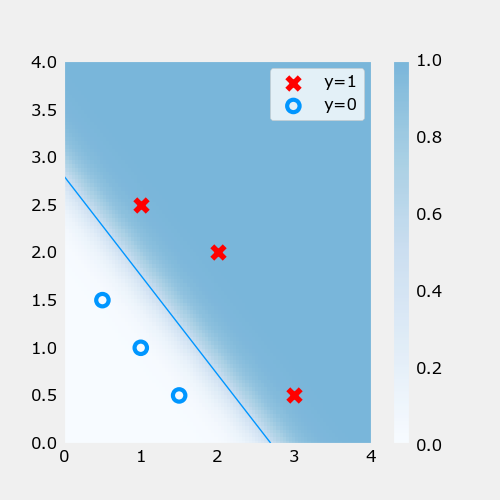

In [29]:
fig,ax =  (plt.subplots(1,1 , figsize = (5,5)))
plt_prob(ax,w_out,b_out)

plot_data(X_train,y_train,ax)

x0 = -b_out/w_out[0]
x1 = -b_out/w_out[1]
ax.plot([0,x0],[x1,0] , lw = 1)

In [30]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])

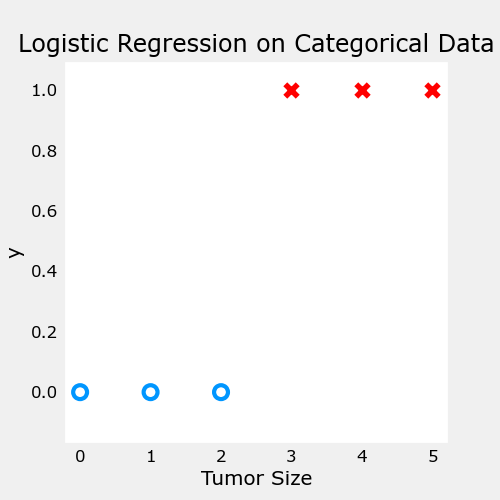

In [33]:
fig , ax = plt.subplots(1,1, figsize = (5,5))
plt_tumor_data(x_train,y_train , ax)

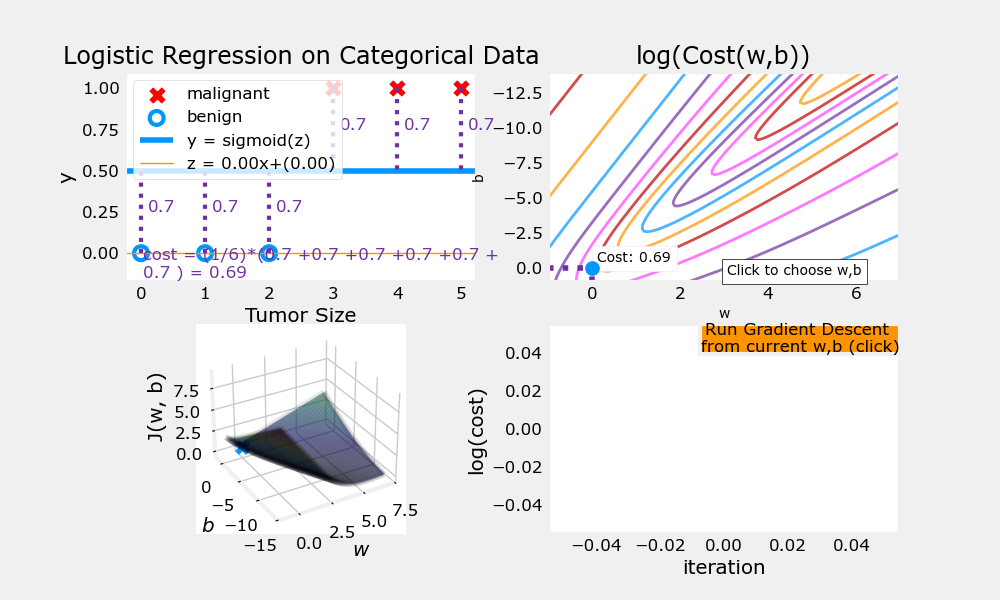

In [34]:
w_range = np.array([-1, 7])
b_range = np.array([1, -14])
quad  = plt_quad_logistic(x_train,y_train,w_range,b_range)